In [39]:
import geopandas as gpd

linkGit='https://github.com/MabelDeZela/REPMABEL/raw/main/'
linkWorldMaps='worldMaps.gpkg'

In [40]:
gpd.list_layers(linkGit+linkWorldMaps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


In [41]:
countries=gpd.read_file(linkGit+linkWorldMaps,layer='countries')

countries

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,South Sudan,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,Indonesia,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,East Timor,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,Curacao (Netherlands),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


In [42]:
import pandas as pd

someDataLink='some_dataworld.csv'

someData=pd.read_csv(linkGit+someDataLink)

someData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    object 
 1   iso2          171 non-null    object 
 2   iso3          172 non-null    object 
 3   region        172 non-null    object 
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.6+ KB


In [43]:
someData.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


In [46]:
someData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    object 
 1   iso2          171 non-null    object 
 2   iso3          172 non-null    object 
 3   region        172 non-null    object 
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.6+ KB


In [47]:
countries.COUNTRY.head()
#geodata

,COUNTRY
0,Aruba (Netherlands)
1,Antigua and Barbuda
2,Afghanistan
3,Algeria
4,Azerbaijan


In [48]:
someData.Country.head()
#dataframe

,Country
0,AFGHANISTAN
1,ALBANIA
2,ALGERIA
3,ANGOLA
4,ANTIGUA AND BARBUDA


In [49]:
countries.rename(columns={'COUNTRY':'Country'},inplace=True)

In [50]:
countries['Country']=countries.Country.str.upper()

In [51]:
onlyDF=set(someData.Country)- set(countries.Country)
onlyGDF=set(countries.Country)- set(someData.Country)

In [52]:
onlyDF

{'BAHAMAS (THE)',
 'BOLIVIA (PLURINATIONAL STATE OF)',
 'BRUNEI DARUSSALAM',
 'CABO VERDE',
 'CENTRAL AFRICAN REPUBLIC (THE)',
 'COMOROS (THE)',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
 'CONGO (THE)',
 "CÔTE D'IVOIRE",
 'DOMINICAN REPUBLIC (THE)',
 'ESWATINI',
 'GAMBIA (THE)',
 'IRAN (ISLAMIC REPUBLIC OF)',
 'KOREA (THE REPUBLIC OF)',
 "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
 'MICRONESIA (FEDERATED STATES OF)',
 'MOLDOVA (THE REPUBLIC OF)',
 'NETHERLANDS (THE)',
 'NIGER (THE)',
 'NORTH MACEDONIA',
 'NORTHERN MARIANA ISLANDS (THE)',
 'PHILIPPINES (THE)',
 'RUSSIAN FEDERATION (THE)',
 'SAMOA',
 'SUDAN (THE)',
 'TANZANIA, THE UNITED REPUBLIC OF',
 'TIMOR-LESTE',
 'UNITED ARAB EMIRATES (THE)',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
 'UNITED STATES OF AMERICA (THE)'}

In [53]:
!pip install thefuzz

In [54]:
## for each country in onlyDF, I have to find the BEST match in onlyGDF

[(country, best(country,onlyGDF)) for country in onlyDF]

[('TIMOR-LESTE', ('EAST TIMOR', 81)),
 ('UNITED ARAB EMIRATES (THE)', ('UNITED ARAB EMIRATES', 95)),
 ('IRAN (ISLAMIC REPUBLIC OF)', ('IRAN', 90)),
 ('BOLIVIA (PLURINATIONAL STATE OF)', ('BOLIVIA', 90)),
 ('NORTH MACEDONIA', ('MACEDONIA', 90)),
 ('BAHAMAS (THE)', ('BAHAMAS', 90)),
 ("LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)", ('CZECH REPUBLIC', 86)),
 ('COMOROS (THE)', ('COMOROS', 90)),
 ('BRUNEI DARUSSALAM', ('BRUNEI', 90)),
 ('CABO VERDE', ('CAPE VERDE', 80)),
 ('NORTHERN MARIANA ISLANDS (THE)', ('NORTHERN MARIANA ISLANDS (US)', 91)),
 ("CÔTE D'IVOIRE", ('IVORY COAST', 58)),
 ('DOMINICAN REPUBLIC (THE)', ('DOMINICAN REPUBLIC', 95)),
 ('NETHERLANDS (THE)', ('NETHERLANDS', 95)),
 ('UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
  ('UNITED KINGDOM', 90)),
 ('CENTRAL AFRICAN REPUBLIC (THE)', ('CENTRAL AFRICAN REPUBLIC', 95)),
 ('SAMOA', ('WESTERN SAMOA', 90)),
 ('MOLDOVA (THE REPUBLIC OF)', ('MOLDOVA', 90)),
 ('SUDAN (THE)', ('SUDAN', 90)),
 ('CONGO (THE)', ('CONGO', 90)),
 (

In [55]:

[(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF]

[('TIMOR-LESTE', 'EAST TIMOR', 81),
 ('UNITED ARAB EMIRATES (THE)', 'UNITED ARAB EMIRATES', 95),
 ('IRAN (ISLAMIC REPUBLIC OF)', 'IRAN', 90),
 ('BOLIVIA (PLURINATIONAL STATE OF)', 'BOLIVIA', 90),
 ('NORTH MACEDONIA', 'MACEDONIA', 90),
 ('BAHAMAS (THE)', 'BAHAMAS', 90),
 ("LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)", 'CZECH REPUBLIC', 86),
 ('COMOROS (THE)', 'COMOROS', 90),
 ('BRUNEI DARUSSALAM', 'BRUNEI', 90),
 ('CABO VERDE', 'CAPE VERDE', 80),
 ('NORTHERN MARIANA ISLANDS (THE)', 'NORTHERN MARIANA ISLANDS (US)', 91),
 ("CÔTE D'IVOIRE", 'IVORY COAST', 58),
 ('DOMINICAN REPUBLIC (THE)', 'DOMINICAN REPUBLIC', 95),
 ('NETHERLANDS (THE)', 'NETHERLANDS', 95),
 ('UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)',
  'UNITED KINGDOM',
  90),
 ('CENTRAL AFRICAN REPUBLIC (THE)', 'CENTRAL AFRICAN REPUBLIC', 95),
 ('SAMOA', 'WESTERN SAMOA', 90),
 ('MOLDOVA (THE REPUBLIC OF)', 'MOLDOVA', 90),
 ('SUDAN (THE)', 'SUDAN', 90),
 ('CONGO (THE)', 'CONGO', 90),
 ('UNITED STATES OF AMERICA (THE)', 'UNI

In [56]:
pd.DataFrame([(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF])
#now I have 3 columns

,0,1,2
0,TIMOR-LESTE,EAST TIMOR,81
1,UNITED ARAB EMIRATES (THE),UNITED ARAB EMIRATES,95
2,IRAN (ISLAMIC REPUBLIC OF),IRAN,90
3,BOLIVIA (PLURINATIONAL STATE OF),BOLIVIA,90
4,NORTH MACEDONIA,MACEDONIA,90
5,BAHAMAS (THE),BAHAMAS,90
6,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),CZECH REPUBLIC,86
7,COMOROS (THE),COMOROS,90
8,BRUNEI DARUSSALAM,BRUNEI,90
9,CABO VERDE,CAPE VERDE,80


In [57]:
pd.DataFrame([(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF]).sort_values(by=2)
#reordeno

,0,1,2
11,CÔTE D'IVOIRE,IVORY COAST,58
22,ESWATINI,LIECHTENSTEIN,60
9,CABO VERDE,CAPE VERDE,80
0,TIMOR-LESTE,EAST TIMOR,81
28,KOREA (THE REPUBLIC OF),SOUTH KOREA,86
6,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),CZECH REPUBLIC,86
5,BAHAMAS (THE),BAHAMAS,90
4,NORTH MACEDONIA,MACEDONIA,90
8,BRUNEI DARUSSALAM,BRUNEI,90
7,COMOROS (THE),COMOROS,90


In [58]:
countries.Country[countries.Country.str.contains('SWAZ|LAO|SAMOA|KORE')]

,Country
9,AMERICAN SAMOA (US)
120,NORTH KOREA
122,SOUTH KOREA
126,LAOS
242,WESTERN SAMOA
243,SWAZILAND


In [59]:
manualChanges={'SWAZILAND':'ESWATINI',
               'LAOS':"LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
               'SOUTH KOREA':'KOREA (THE REPUBLIC OF)',
               'WESTERN SAMOA':'SAMOA',
              }

countries.replace(to_replace={'Country':manualChanges},inplace=True)

In [60]:
onlyDF=set(someData.Country)- set(countries.Country)
onlyGDF=set(countries.Country)- set(someData.Country)

In [61]:
pd.DataFrame([(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF]).sort_values(2)

,0,1,2
10,CÔTE D'IVOIRE,IVORY COAST,58
8,CABO VERDE,CAPE VERDE,80
0,TIMOR-LESTE,EAST TIMOR,81
2,IRAN (ISLAMIC REPUBLIC OF),IRAN,90
6,COMOROS (THE),COMOROS,90
5,BAHAMAS (THE),BAHAMAS,90
3,BOLIVIA (PLURINATIONAL STATE OF),BOLIVIA,90
4,NORTH MACEDONIA,MACEDONIA,90
15,MOLDOVA (THE REPUBLIC OF),MOLDOVA,90
7,BRUNEI DARUSSALAM,BRUNEI,90


In [62]:
changesToDF={country: best(country,onlyGDF)[0] for country in onlyDF}
changesToDF

{'TIMOR-LESTE': 'EAST TIMOR',
 'UNITED ARAB EMIRATES (THE)': 'UNITED ARAB EMIRATES',
 'IRAN (ISLAMIC REPUBLIC OF)': 'IRAN',
 'BOLIVIA (PLURINATIONAL STATE OF)': 'BOLIVIA',
 'NORTH MACEDONIA': 'MACEDONIA',
 'BAHAMAS (THE)': 'BAHAMAS',
 'COMOROS (THE)': 'COMOROS',
 'BRUNEI DARUSSALAM': 'BRUNEI',
 'CABO VERDE': 'CAPE VERDE',
 'NORTHERN MARIANA ISLANDS (THE)': 'NORTHERN MARIANA ISLANDS (US)',
 "CÔTE D'IVOIRE": 'IVORY COAST',
 'DOMINICAN REPUBLIC (THE)': 'DOMINICAN REPUBLIC',
 'NETHERLANDS (THE)': 'NETHERLANDS',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)': 'UNITED KINGDOM',
 'CENTRAL AFRICAN REPUBLIC (THE)': 'CENTRAL AFRICAN REPUBLIC',
 'MOLDOVA (THE REPUBLIC OF)': 'MOLDOVA',
 'SUDAN (THE)': 'SUDAN',
 'CONGO (THE)': 'CONGO',
 'UNITED STATES OF AMERICA (THE)': 'UNITED STATES',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)': 'DEMOCRATIC REPUBLIC OF THE CONGO',
 'NIGER (THE)': 'NIGER',
 'TANZANIA, THE UNITED REPUBLIC OF': 'TANZANIA',
 'RUSSIAN FEDERATION (THE)': 'RUSSIA',
 'PHILIP

In [63]:
someData.replace(to_replace={'Country':changesToDF},inplace=True)

In [64]:
onlyDF=set(someData.Country)- set(countries.Country)
onlyGDF=set(countries.Country)- set(someData.Country)
[(country, best(country,onlyGDF)) for country in onlyDF]

[]

In [65]:
theMapAndData=countries.merge(someData, on='Country')

In [66]:
theMapAndData.info()
#vemos que tenemos

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       172 non-null    object  
 1   geometry      172 non-null    geometry
 2   iso2          171 non-null    object  
 3   iso3          172 non-null    object  
 4   region        172 non-null    object  
 5   fragility     172 non-null    float64 
 6   co2           172 non-null    int64   
 7   sq_km         172 non-null    int64   
 8   num_airports  172 non-null    int64   
 9   population    172 non-null    int64   
 10  mobiles       172 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 14.9+ KB


In [44]:
regiones_deseadas = ['NORTH AMERICA', 'SOUTH AMERICA', 'CENTRAL AMERICA AND THE CARIBBEAN']

In [69]:
mapa_filtrado = theMapAndData[theMapAndData['region'].isin(regiones_deseadas)]

<Axes: >

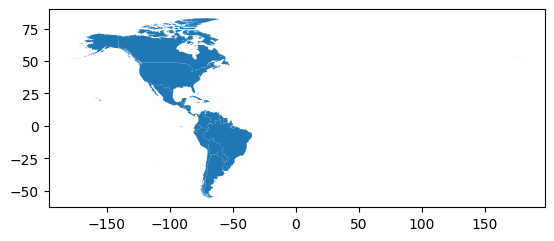

In [73]:
mapa_filtrado.plot()

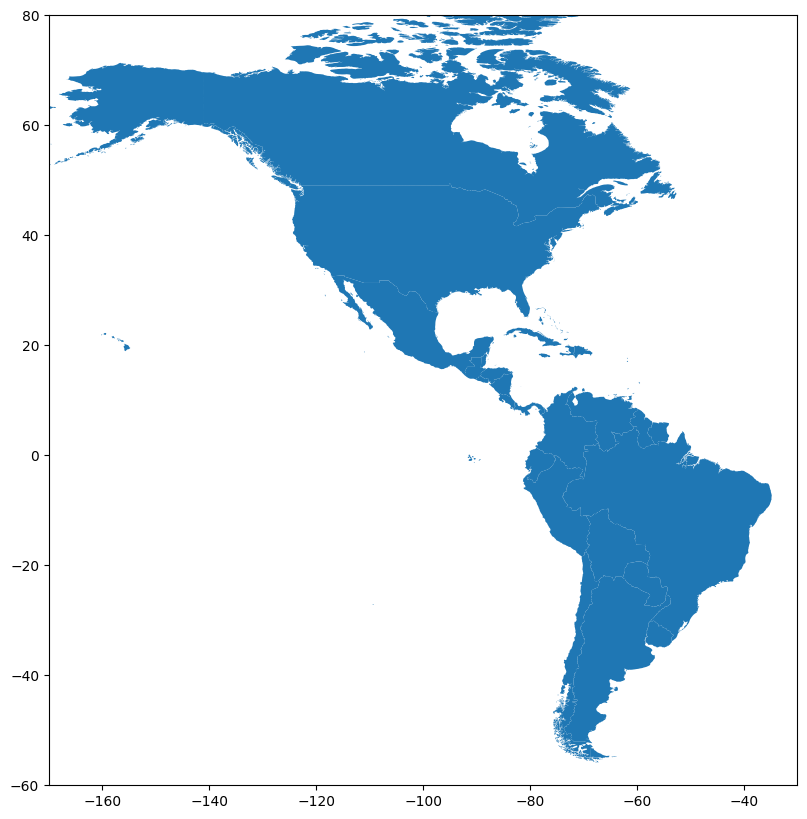

In [74]:
import matplotlib.pyplot as plt

# Dibujamos el mapa filtrado
ax = mapa_filtrado.plot(figsize=(10, 10))

# Ajustamos los límites de la vista
ax.set_xlim([-170, -30]) # Longitud
ax.set_ylim([-60, 80])   # Latitud

plt.show()

In [75]:
mapa_filtrado.to_file("worldindicators.json")
#guardo el mapa

DOT DENSITY MAP

In [76]:
mapa_filtrado.region.value_counts()

,count
region,
CENTRAL AMERICA AND THE CARIBBEAN,16
SOUTH AMERICA,12
NORTH AMERICA,3


In [85]:
justDots=mapa_filtrado.copy()
dot_value = 100000
justDots['num_dots'] = (justDots['mobiles'] / dot_value).astype(int)

In [86]:
justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)

In [87]:
justDots

0    0        POINT (-61.7601 17.58455)
7    0      POINT (-72.89762 -50.02515)
     1      POINT (-72.74887 -50.59282)
     2       POINT (-72.49779 -49.5811)
     3      POINT (-72.29751 -47.91947)
                       ...             
161  183      POINT (-60.67497 7.60339)
     184       POINT (-60.66708 5.0665)
     185       POINT (-60.62377 7.9708)
     186      POINT (-60.52042 7.02216)
     187      POINT (-60.21337 8.15113)
Name: sampled_points, Length: 11508, dtype: geometry

In [88]:
justDots.reset_index(drop=True, inplace=True)
Mapa_dots=gpd.GeoDataFrame(geometry=justDots)
Mapa_dots

,geometry
0,POINT (-61.7601 17.58455)
1,POINT (-72.89762 -50.02515)
2,POINT (-72.74887 -50.59282)
3,POINT (-72.49779 -49.5811)
4,POINT (-72.29751 -47.91947)
...,...
11503,POINT (-60.67497 7.60339)
11504,POINT (-60.66708 5.0665)
11505,POINT (-60.62377 7.9708)
11506,POINT (-60.52042 7.02216)


In [89]:
Mapa_dots.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  11508 non-null  geometry
dtypes: geometry(1)
memory usage: 90.0 KB


<Axes: >

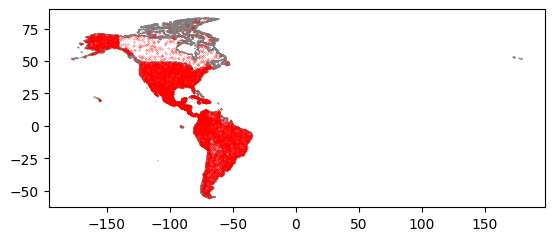

In [90]:
base=mapa_filtrado.plot(facecolor="white",#color of polygon fill
               edgecolor='grey') #color of border
Mapa_dots.plot(markersize=0.05, color='red',ax=base)

<Axes: >

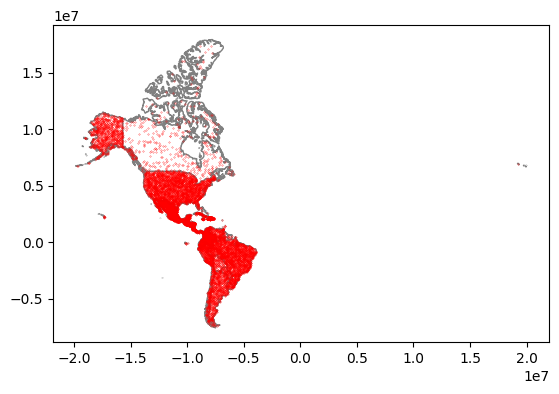

In [138]:
base=mapa_filtrado.to_crs(3857).plot(facecolor="white",
                              edgecolor='grey')
Mapa_dots.to_crs(3857).plot(markersize=0.05, color='red',ax=base)

In [139]:
mapafiltrado_3857=mapa_filtrado.to_crs(3857)
Mapa_dots_3857=Mapa_dots.to_crs(3857)

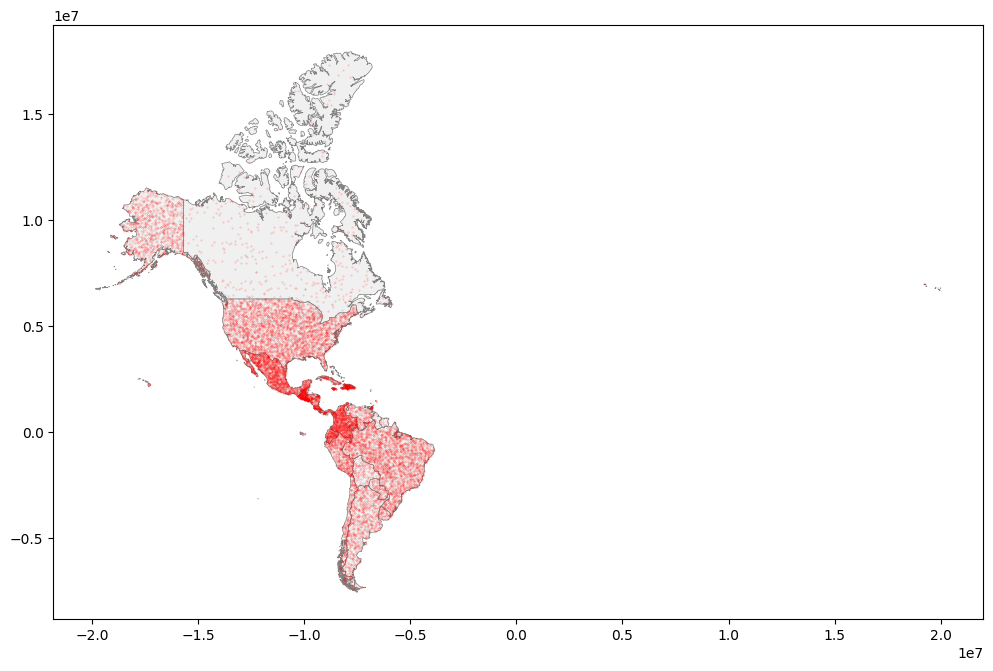

In [140]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

mapafiltrado_3857.plot(ax=ax, facecolor="#f0f0f0", edgecolor="grey", linewidth=0.5)
Mapa_dots_3857.plot(ax=ax, markersize=0.1, color='red', alpha=0.3)


plt.show()

PROPORTINAL SYMBOL MAP

In [141]:
Mapa_3857_centroids = mapafiltrado_3857.copy()


Mapa_3857_centroids['geometry'] = Mapa_3857_centroids['geometry'].centroid

In [142]:
Mapa_3857_centroids['size'] = Mapa_3857_centroids['mobiles'].apply(lambda x: x**0.5/100)

<Axes: >

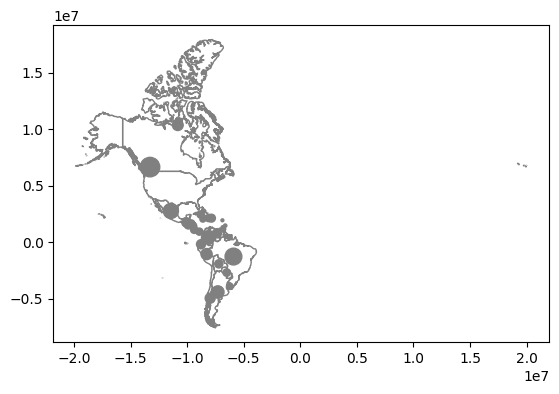

In [143]:
base=mapafiltrado_3857.plot(facecolor="white",
                      edgecolor='grey')
# Plot the centroids on top
Mapa_3857_centroids.plot(
    ax=base,
    markersize=Mapa_3857_centroids['size'],
    color='grey'
)

In [144]:
base=mapafiltrado_3857[mapafiltrado_3857.Country=="SEYCHELLES"].explore()
Mapa_3857_centroids[Mapa_3857_centroids.Country=="SEYCHELLES"].explore(m=base,color="red")

/tmp/ipykernel_4650/2663678273.py:1: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  base=mapafiltrado_3857[mapafiltrado_3857.Country=="SEYCHELLES"].explore()
/tmp/ipykernel_4650/2663678273.py:2: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  Mapa_3857_centroids[Mapa_3857_centroids.Country=="SEYCHELLES"].explore(m=base,color="red")


In [145]:
# replace the points
Mapa_3857_centroids["geometry"]=mapafiltrado_3857.representative_point()

In [146]:
base=mapafiltrado_3857[mapafiltrado_3857.Country=="SEYCHELLES"].explore()
Mapa_3857_centroids[Mapa_3857_centroids.Country=="SEYCHELLES"].explore(m=base,color="red")

/tmp/ipykernel_4650/2663678273.py:1: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  base=mapafiltrado_3857[mapafiltrado_3857.Country=="SEYCHELLES"].explore()
/tmp/ipykernel_4650/2663678273.py:2: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  Mapa_3857_centroids[Mapa_3857_centroids.Country=="SEYCHELLES"].explore(m=base,color="red")


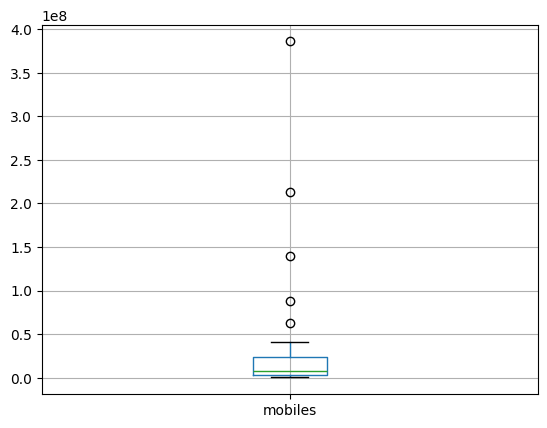

In [147]:
boxplotInfo=Mapa_3857_centroids.boxplot(column='mobiles',return_type="dict")

In [148]:
outliers=boxplotInfo['fliers'][0].get_ydata()
## see
outliers

array([62700000, 213000000, 87400000, 140000000, 386000000], dtype=object)

In [149]:
Mapa_3857_centroids[Mapa_3857_centroids.mobiles.isin(outliers)]

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size
7,ARGENTINA,POINT (-7222472.664 -4671592.89),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332
22,BRAZIL,POINT (-5538242.157 -1708737.365),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195
37,COLOMBIA,POINT (-8082408.487 462860.859),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967
108,MEXICO,POINT (-11395168.809 2747350.134),MX,MEX,NORTH AMERICA,69.7,463739000,1964375,1580,130739927,140000000,118.321596
157,UNITED STATES,POINT (-11126153.32 4614235.662),US,USA,NORTH AMERICA,38.0,5144361000,9833517,16116,341963408,386000000,196.468827


In [150]:
Mapa_3857_centroids['mobiles_outlier']=Mapa_3857_centroids.mobiles.isin(outliers)*1

## see
Mapa_3857_centroids

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size,mobiles_outlier
0,ANTIGUA AND BARBUDA,POINT (-6877210.262 1928489.685),AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000,4.289522,0
7,ARGENTINA,POINT (-7222472.664 -4671592.89),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332,1
11,BARBADOS,POINT (-6631703.447 1482440.161),BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000,5.683309,0
14,BAHAMAS,POINT (-8163617.894 2405994.008),BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000,6.324555,0
16,BELIZE,POINT (-9876437.181 1945510.649),BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000,5.138093,0
18,BOLIVIA,POINT (-7084892.346 -1852010.791),BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,34.641016,0
22,BRAZIL,POINT (-5538242.157 -1708737.365),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195,1
27,CANADA,POINT (-13015967.21 8432370.165),CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000,60.415230,0
34,CHILE,POINT (-8047606.295 -4568573.663),CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,51.672043,0
37,COLOMBIA,POINT (-8082408.487 462860.859),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967,1


<Axes: >

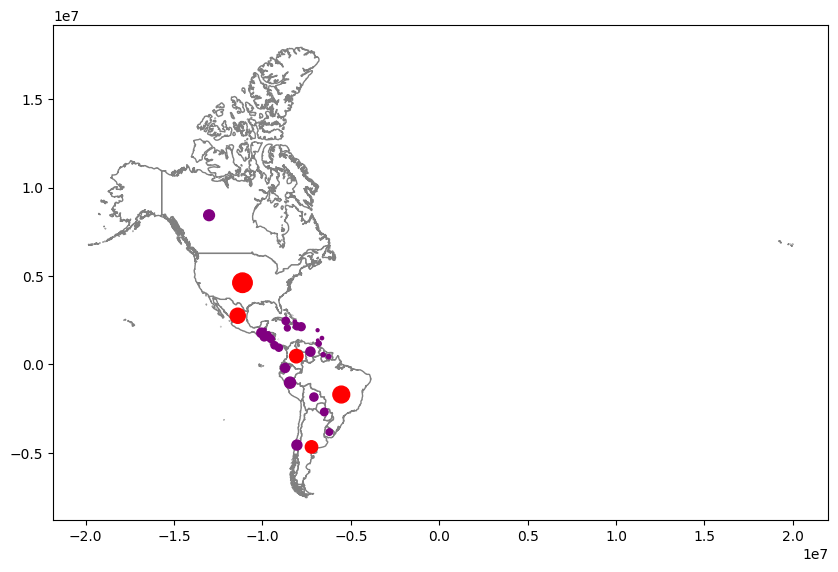

In [153]:
base = mapafiltrado_3857.plot(color='white', edgecolor='grey', figsize=(10,10))

# Define color map
mapcolor = {1: 'red', 0: 'purple'}

# Plot the centroids on top
Mapa_3857_centroids.plot(
    ax=base,
    markersize=Mapa_3857_centroids['size'],
    color=Mapa_3857_centroids['mobiles_outlier'].map(mapcolor)
)

In [154]:
# Create explicit copies of the DataFrames
Mapa_3857_centroids_out = Mapa_3857_centroids[Mapa_3857_centroids.mobiles_outlier==1].copy()
Mapa_3857_centroids_no_out = Mapa_3857_centroids[Mapa_3857_centroids.mobiles_outlier==0].copy()

In [155]:
Mapa_3857_centroids_out['size'] = Mapa_3857_centroids_out['mobiles'].apply(lambda x: x**0.5 / 50)
Mapa_3857_centroids_no_out['size'] = Mapa_3857_centroids_no_out['mobiles'].apply(lambda x: x**0.5 / 50)

<Axes: >

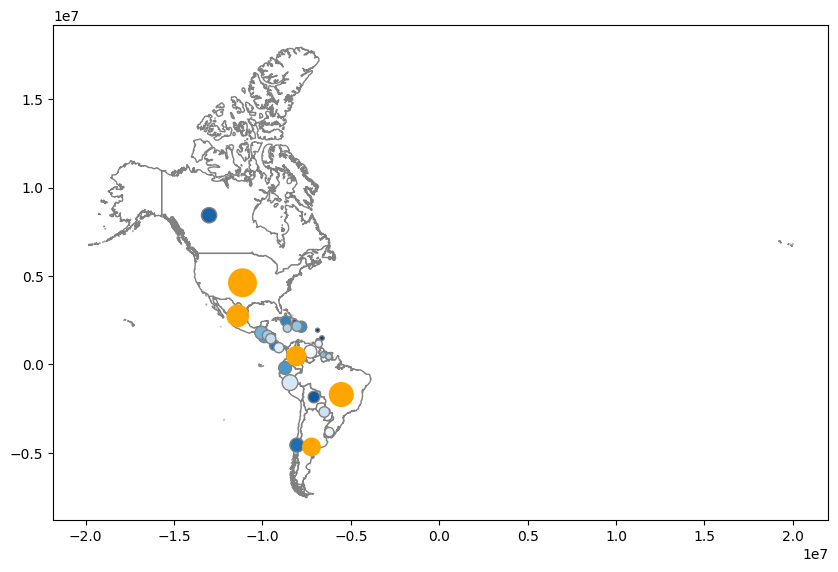

In [187]:
base=mapafiltrado_3857.plot(color='white', edgecolor='grey',figsize=(10,10))

Mapa_3857_centroids_no_out.plot(
    ax=base,
    markersize=Mapa_3857_centroids_no_out['size'],
    edgecolor='grey',
    c=Mapa_3857_centroids_no_out['size'],
    cmap='Blues_r'
)
Mapa_3857_centroids_out.plot(
    ax=base,
    markersize=Mapa_3857_centroids_out['size'],
    color='orange'
)

<Axes: >

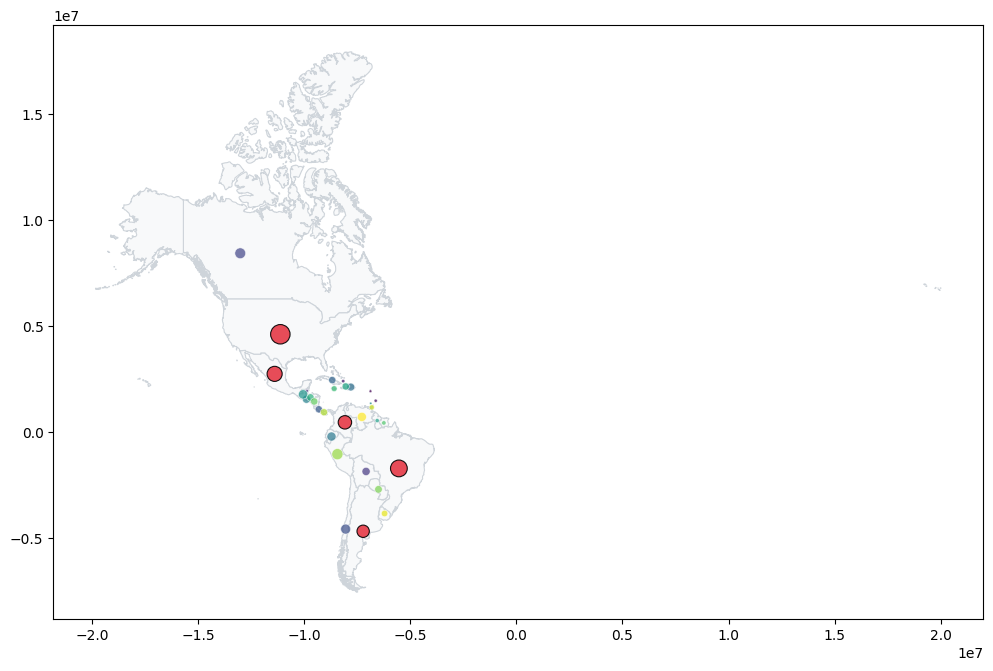

In [158]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))
mapafiltrado_3857.plot(ax=ax, color='#f8f9fa', edgecolor='#ced4da', linewidth=0.8)

Mapa_3857_centroids_no_out.plot(
    ax=ax,
    markersize=Mapa_3857_centroids_no_out['size'] * 0.5,
    edgecolor='white',
    linewidth=0.5,
    c=Mapa_3857_centroids_no_out['size'],
    cmap='viridis',
    alpha=0.7
)

Mapa_3857_centroids_out.plot(
    ax=ax,
    markersize=Mapa_3857_centroids_out['size'] * 0.5,
    color='#e63946', # Un rojo/naranja más vibrante
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)



**Choropleths**

<Axes: >

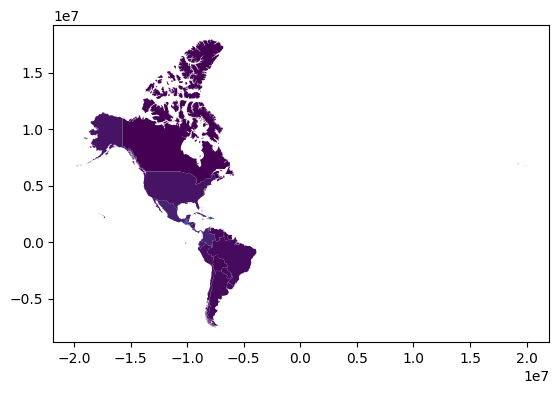

In [159]:
mapafiltrado_3857.plot(mapafiltrado_3857.mobiles/mapafiltrado_3857.sq_km)

In [160]:
 ! pip show numba mapclassify numpy

Name: numba
Version: 0.60.0
Summary: compiling Python code using LLVM
Home-page: https://numba.pydata.org
Author: 
Author-email: 
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: llvmlite, numpy
Required-by: librosa, pynndescent, pytensor, quantecon, segregation, shap, stumpy, umap-learn
---
Name: mapclassify
Version: 2.10.0
Summary: Classification Schemes for Choropleth Maps.
Home-page: 
Author: 
Author-email: 
License: BSD 3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: networkx, numpy, pandas, scikit-learn, scipy
Required-by: giddy, pysal, segregation, splot, spopt
---
Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are


In [186]:
mapafiltrado_3857['mobiles_density']=mapafiltrado_3857.mobiles/mapafiltrado_3857.sq_km

In [166]:
import mapclassify
import numpy as np

np.random.seed(12345) # so we all get the same results!

# let's try 5 intervals
K=5
theVar=mapafiltrado_3857['mobiles_density']
# same interval width, easy interpretation
ei5 = mapclassify.EqualInterval(theVar, k=K)
# same interval width based on standard deviation, easy - but not as the previous one, poor when high skewness
msd = mapclassify.StdMean(theVar)
# interval width varies, counts per interval are close, not easy to grasp, repeated values complicate cuts
q5=mapclassify.Quantiles(theVar,k=K)

# based on similarity, good for multimodal data
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
# based on similarity, good for skewed data
ht = mapclassify.HeadTailBreaks(theVar) # no K needed
# based on similarity, optimizer
fj5 = mapclassify.FisherJenks(theVar, k=K)
# based on similarity, optimizer
jc5 = mapclassify.JenksCaspall(theVar, k=K)
# based on similarity, optimizer
mp5 = mapclassify.MaxP(theVar, k=K)

In [165]:
class5 = ei5,msd, q5,mb5,  ht, fj5, jc5, mp5
# Collect ADCM for each classifier
fits = np.array([ c.adcm for c in class5])
# Convert ADCM scores to a DataFrame
adcms = pd.DataFrame(fits)
# Add classifier names
adcms['classifier'] = [c.name for c in class5]
# Add column names to the ADCM
adcms.columns = ['ADCM', 'Classifier']

<Axes: ylabel='Classifier'>

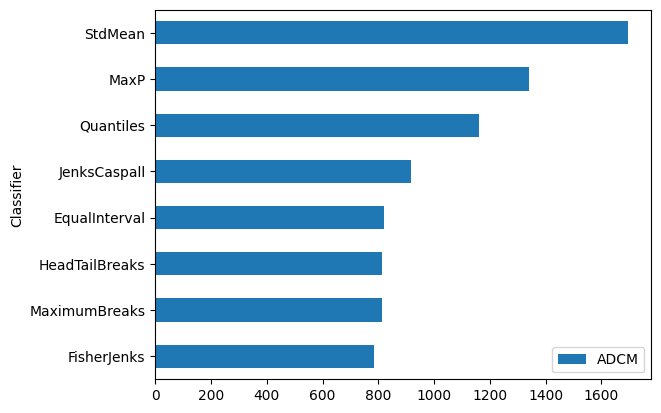

In [167]:
adcms.sort_values('ADCM').plot.barh(x='Classifier')

In [169]:
mapafiltrado_3857['mobiles_density_FJ5'] = fj5.yb

In [170]:

mapafiltrado_3857[['mobiles_density','mobiles_density_FJ5']].head(20)

,mobiles_density,mobiles_density_FJ5
0,415.349887,2
7,22.550712,0
11,751.162791,4
14,28.818444,0
16,11.495254,0
18,10.923182,0
22,25.012418,0
27,3.655604,0
34,35.312696,0
37,76.740041,0


In [171]:
# renaming
newLabelsForLevels={0:"0_VeryLow", 1:"1_Low", 2:"2_Middle", 3:"3_High", 4:"4_VeryHigh"}

mapafiltrado_3857['mobiles_density_FJ5_cat']=mapafiltrado_3857.loc[:,'mobiles_density_FJ5'].replace(newLabelsForLevels)


mapafiltrado_3857[['mobiles_density','mobiles_density_FJ5','mobiles_density_FJ5_cat']].head(20)

,mobiles_density,mobiles_density_FJ5,mobiles_density_FJ5_cat
0,415.349887,2,2_Middle
7,22.550712,0,0_VeryLow
11,751.162791,4,4_VeryHigh
14,28.818444,0,0_VeryLow
16,11.495254,0,0_VeryLow
18,10.923182,0,0_VeryLow
22,25.012418,0,0_VeryLow
27,3.655604,0,0_VeryLow
34,35.312696,0,0_VeryLow
37,76.740041,0,0_VeryLow


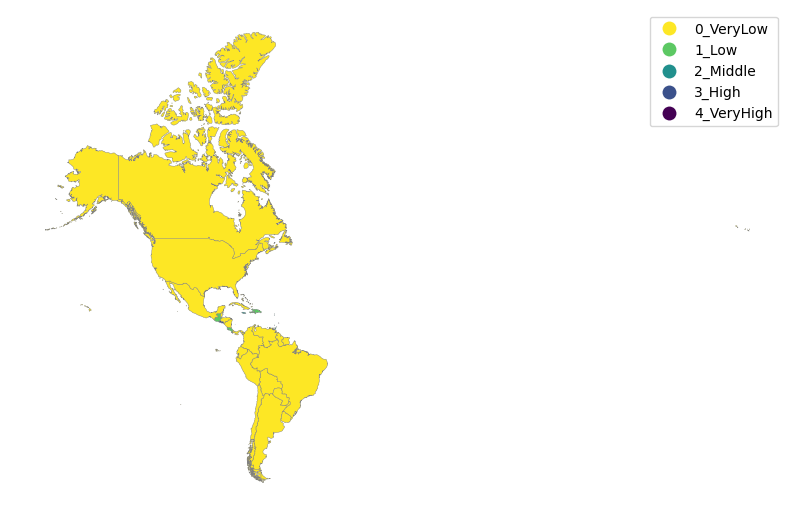

In [183]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))
mapafiltrado_3857.plot(column='mobiles_density_FJ5_cat', # variable to plot
                 cmap='viridis_r',
                 categorical=True,
                 edgecolor='grey', # border color
                 linewidth=0.3,
                 legend=True, #legend
                 ax=ax
       )

ax.set_axis_off()

<Axes: >

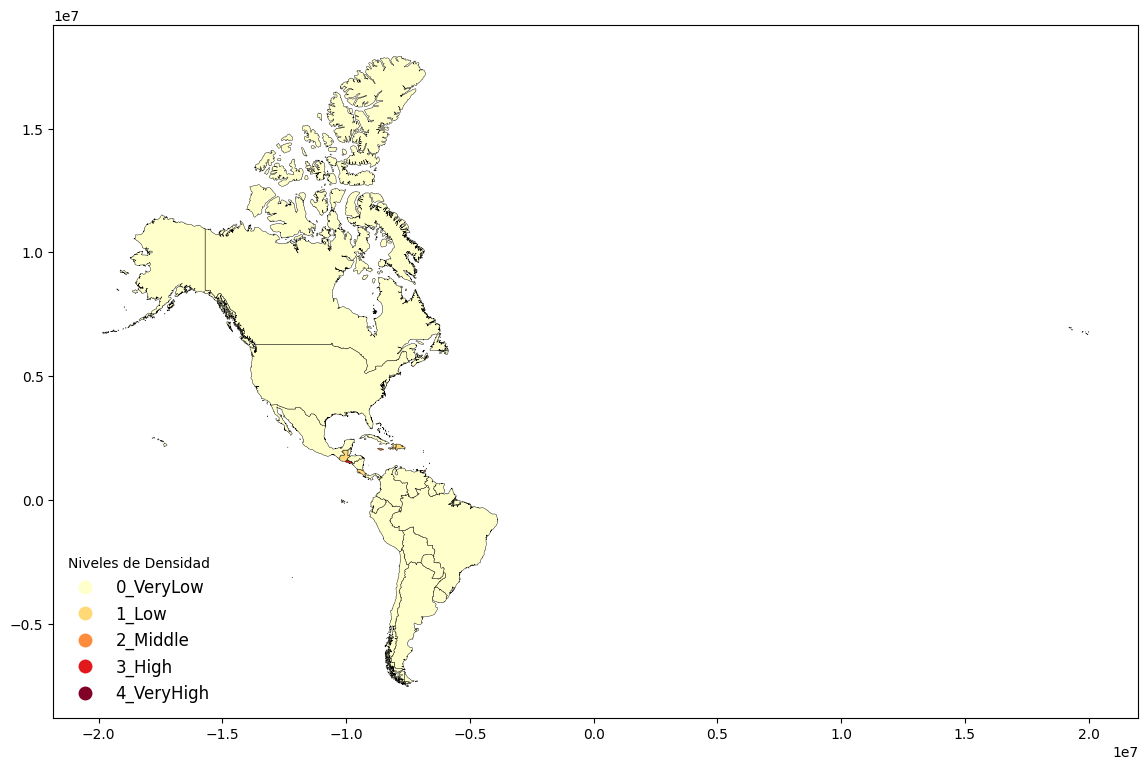

In [173]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(14, 12))

# 2. Graficamos
mapafiltrado_3857.plot(
    column='mobiles_density_FJ5_cat',
    cmap='YlOrRd',      # Esta paleta es mucho más clara y profesional
    categorical=True,
    edgecolor='black',  # Bordes negros finos para que resalten sobre el amarillo
    linewidth=0.3,
    legend=True,
    legend_kwds={
        'loc': 'lower left',
        'title': "Niveles de Densidad",
        'frameon': False,
        'fontsize': 12
    },
    ax=ax
)

SAVING

In [188]:

## Find only GeoDataFrames
geodataframe_list = [var for var in globals() if isinstance(globals()[var], gpd.GeoDataFrame)]

print("List of GeoDataFrames in memory:")
for name in geodataframe_list:
    print(name)

List of GeoDataFrames in memory:
countries
_5
theMapAndData
_41
mapa_filtrado
Mapa_dots
_80
_88
mapafiltrado_8857
Mapa_dots_8857
Mapa_8857_centroids
_111
_112
Mapa_8857_centroids_out
Mapa_8857_centroids_no_out
mapafiltrado_3857
Mapa_dots_3857
Mapa_3857_centroids
_149
_150
Mapa_3857_centroids_out
Mapa_3857_centroids_no_out


In [176]:
# for choropleth and base map
mapafiltrado_3857.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 31 entries, 0 to 161
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Country                  31 non-null     object  
 1   geometry                 31 non-null     geometry
 2   iso2                     31 non-null     object  
 3   iso3                     31 non-null     object  
 4   region                   31 non-null     object  
 5   fragility                31 non-null     float64 
 6   co2                      31 non-null     int64   
 7   sq_km                    31 non-null     int64   
 8   num_airports             31 non-null     int64   
 9   population               31 non-null     int64   
 10  mobiles                  31 non-null     int64   
 11  mobiles_density          31 non-null     float64 
 12  mobiles_density_FJ5      31 non-null     int64   
 13  mobiles_density_FJ5_cat  31 non-null     object  
dtypes: float

In [177]:
# for DDMs
Mapa_dots_3857.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  11508 non-null  geometry
dtypes: geometry(1)
memory usage: 90.0 KB


In [178]:
# for PSMs
Mapa_3857_centroids.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 31 entries, 0 to 161
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Country          31 non-null     object  
 1   geometry         31 non-null     geometry
 2   iso2             31 non-null     object  
 3   iso3             31 non-null     object  
 4   region           31 non-null     object  
 5   fragility        31 non-null     float64 
 6   co2              31 non-null     int64   
 7   sq_km            31 non-null     int64   
 8   num_airports     31 non-null     int64   
 9   population       31 non-null     int64   
 10  mobiles          31 non-null     int64   
 11  size             31 non-null     float64 
 12  mobiles_outlier  31 non-null     int64   
dtypes: float64(2), geometry(1), int64(6), object(4)
memory usage: 3.4+ KB


In [179]:
# for PSMs
Mapa_3857_centroids_out.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 5 entries, 7 to 157
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Country          5 non-null      object  
 1   geometry         5 non-null      geometry
 2   iso2             5 non-null      object  
 3   iso3             5 non-null      object  
 4   region           5 non-null      object  
 5   fragility        5 non-null      float64 
 6   co2              5 non-null      int64   
 7   sq_km            5 non-null      int64   
 8   num_airports     5 non-null      int64   
 9   population       5 non-null      int64   
 10  mobiles          5 non-null      int64   
 11  size             5 non-null      float64 
 12  mobiles_outlier  5 non-null      int64   
dtypes: float64(2), geometry(1), int64(6), object(4)
memory usage: 560.0+ bytes


In [180]:
# for PSMs
Mapa_3857_centroids_no_out.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 26 entries, 0 to 161
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Country          26 non-null     object  
 1   geometry         26 non-null     geometry
 2   iso2             26 non-null     object  
 3   iso3             26 non-null     object  
 4   region           26 non-null     object  
 5   fragility        26 non-null     float64 
 6   co2              26 non-null     int64   
 7   sq_km            26 non-null     int64   
 8   num_airports     26 non-null     int64   
 9   population       26 non-null     int64   
 10  mobiles          26 non-null     int64   
 11  size             26 non-null     float64 
 12  mobiles_outlier  26 non-null     int64   
dtypes: float64(2), geometry(1), int64(6), object(4)
memory usage: 2.8+ KB


In [181]:
mapafiltrado_3857.to_file("mapafiltrado_3857.gpkg",driver='GPKG',layer='continent')
Mapa_dots_3857.to_file("mapafiltrado_3857.gpkg",driver='GPKG',layer='mobiles_ddm')
Mapa_3857_centroids.to_file("mapafiltrado_3857.gpkg",driver='GPKG',layer='mobiles_psm')
Mapa_3857_centroids_out.to_file("mapafiltrado_3857.gpkg",driver='GPKG',layer='outlier_mobiles_psm')
Mapa_3857_centroids_no_out.to_file("mapafiltrado_3857.gpkg",driver='GPKG',layer='no_outlier_mobiles_psm')